## Data Sources

Mental health data: IHME Global Burden of Disease, via Kaggle (Oleksii Zhukov)
Mobile data: World Bank — IT.CEL.SETS.P2

## Wide Format

In [20]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pycountry_convert as pc

mobile = pd.read_csv('../csv/API_IT.CEL.SETS.P2_DS2_en_csv_v2_1834.csv', skiprows=4)
mobile.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Mobile cellular subscriptions (per 100 people),IT.CEL.SETS.P2,0.0,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,131.6820,131.2850,131.0920,130.6480,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Mobile cellular subscriptions (per 100 people),IT.CEL.SETS.P2,0.0,NaN,NaN,NaN,NaN,0.0,...,63.5000,65.2000,67.9000,69.9000,74.7000,77.7000,82.3000,87.3,93.1,NaN
2,Afghanistan,AFG,Mobile cellular subscriptions (per 100 people),IT.CEL.SETS.P2,0.0,NaN,NaN,NaN,NaN,0.0,...,67.0508,59.8109,59.6471,58.0461,56.6945,56.2655,55.5475,NaN,NaN,NaN
3,Africa Western and Central,AFW,Mobile cellular subscriptions (per 100 people),IT.CEL.SETS.P2,0.0,NaN,NaN,NaN,NaN,0.0,...,81.4000,87.8000,91.3000,96.7000,95.2000,102.1000,101.4000,91.8,86.5,NaN
4,Angola,AGO,Mobile cellular subscriptions (per 100 people),IT.CEL.SETS.P2,0.0,NaN,NaN,NaN,NaN,0.0,...,44.0682,42.4589,45.8065,43.7804,44.3869,66.6008,70.0520,NaN,NaN,NaN


## Long Format

In [21]:
mobile_long = mobile.melt(
    id_vars=['Country Name', 'Country Code'],
    var_name='Year',
    value_name='Mobile Subscriptions'
)
mobile_long.head(20)

,Country Name,Country Code,Year,Mobile Subscriptions
0,Aruba,ABW,Indicator Name,Mobile cellular subscriptions (per 100 people)
1,Africa Eastern and Southern,AFE,Indicator Name,Mobile cellular subscriptions (per 100 people)
2,Afghanistan,AFG,Indicator Name,Mobile cellular subscriptions (per 100 people)
3,Africa Western and Central,AFW,Indicator Name,Mobile cellular subscriptions (per 100 people)
4,Angola,AGO,Indicator Name,Mobile cellular subscriptions (per 100 people)
5,Albania,ALB,Indicator Name,Mobile cellular subscriptions (per 100 people)
6,Andorra,AND,Indicator Name,Mobile cellular subscriptions (per 100 people)
7,Arab World,ARB,Indicator Name,Mobile cellular subscriptions (per 100 people)
8,United Arab Emirates,ARE,Indicator Name,Mobile cellular subscriptions (per 100 people)
9,Argentina,ARG,Indicator Name,Mobile cellular subscriptions (per 100 people)


## Mobile Subscriptions Data (World Bank)
World Bank dataset showing mobile cellular subscriptions per 100 people by country from 1960–2025. 
Originally in wide format (one column per year), reshaped to long format for plotting.

In [22]:
mobile_long = mobile_long[pd.to_numeric(mobile_long['Year'], errors='coerce').notna()]
mobile_long['Year'] = mobile_long['Year'].astype(int)
print(mobile_long.head(20))

                    Country Name Country Code  Year Mobile Subscriptions
532                        Aruba          ABW  1960                  0.0
533  Africa Eastern and Southern          AFE  1960                  0.0
534                  Afghanistan          AFG  1960                  0.0
535   Africa Western and Central          AFW  1960                  0.0
536                       Angola          AGO  1960                  0.0
537                      Albania          ALB  1960                  0.0
538                      Andorra          AND  1960                  0.0
539                   Arab World          ARB  1960                  0.0
540         United Arab Emirates          ARE  1960                  NaN
541                    Argentina          ARG  1960                  0.0
542                      Armenia          ARM  1960                  0.0
543               American Samoa          ASM  1960                  0.0
544          Antigua and Barbuda          ATG  1960

## Cleaning Mobile Data
Filtered out non-numeric year values which were metadata artefacts from the World Bank CSV format. 
Also removed rows with no subscription values. Trade-off: lose some rows but data is trustworthy.

In [23]:
mh = pd.read_csv('../csv/Mental health Depression disorder Data.csv')
mh.head(20)

/var/folders/_0/9t8ghdbs3s59dnmc_w11f0hc0000gn/T/ipykernel_74694/353939862.py:1: DtypeWarning: Columns (0: Bipolar disorder (%), 1: Eating disorders (%)) have mixed types. Specify dtype option on import or set low_memory=False.
  mh = pd.read_csv('../csv/Mental health Depression disorder Data.csv')


,index,Entity,Code,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
0,0,Afghanistan,AFG,1990,0.16056,0.697779,0.101855,4.828830,1.677082,4.071831,0.672404
1,1,Afghanistan,AFG,1991,0.160312,0.697961,0.099313,4.829740,1.684746,4.079531,0.671768
2,2,Afghanistan,AFG,1992,0.160135,0.698107,0.096692,4.831108,1.694334,4.088358,0.670644
3,3,Afghanistan,AFG,1993,0.160037,0.698257,0.094336,4.830864,1.705320,4.096190,0.669738
4,4,Afghanistan,AFG,1994,0.160022,0.698469,0.092439,4.829423,1.716069,4.099582,0.669260
5,5,Afghanistan,AFG,1995,0.160076,0.698695,0.09098,4.828337,1.728112,4.104207,0.668746
6,6,Afghanistan,AFG,1996,0.160249,0.698914,0.089709,4.828083,1.737643,4.107500,0.667727
7,7,Afghanistan,AFG,1997,0.160554,0.699127,0.088372,4.827726,1.746891,4.110834,0.666220
8,8,Afghanistan,AFG,1998,0.160931,0.699372,0.08733,4.826971,1.756963,4.114438,0.664676
9,9,Afghanistan,AFG,1999,0.161311,0.699674,0.086267,4.826413,1.770791,4.117633,0.663428


## Mental Health Depression Disorder Data (IHME via Kaggle)
Country-level prevalence data for multiple mental health disorders from 1990–2019. 
Already in long format. Columns include Anxiety, Depression, Bipolar, Schizophrenia, Eating disorders, Drug and Alcohol use.

In [24]:
print(mh['Year'].min(), mh['Year'].max())

0 Year


In [25]:
print(mobile_long.shape)

(17556, 4)


In [26]:
mh['Year'] = pd.to_numeric(mh['Year'], errors='coerce')
print(mh['Year'].min(), mh['Year'].max())

0.0 2019.0


In [27]:
mh = mh[mh['Year'] > 1900]
print(mh['Year'].min(), mh['Year'].max())

1901.0 2019.0


In [28]:
mh = mh[mh['Year'] >= 1990]
print(mh['Year'].min(), mh['Year'].max())

1990.0 2019.0


## Cleaning Mental Health Data
Converted Year to numeric and filtered to 1990 onwards. 
Removed erroneous early rows. Working range is 1990–2019 to align with mobile data.

In [29]:
print(mobile_long['Year'].min(), mobile_long['Year'].max())

1960 2025


In [30]:
print(mh['Code'].nunique())
print(mobile_long['Country Code'].nunique())

235
266


In [31]:
common = set(mh['Code']).intersection(set(mobile_long['Country Code']))
print(len(common))

215


In [32]:
merged = mh.merge(
    mobile_long,
    left_on=['Code', 'Year'],
    right_on=['Country Code', 'Year']
)
merged.head()

,index,Entity,Code,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%),Country Name,Country Code,Mobile Subscriptions
0,0,Afghanistan,AFG,1990.0,0.16056,0.697779,0.101855,4.828830,1.677082,4.071831,0.672404,Afghanistan,AFG,0.0
1,1,Afghanistan,AFG,1991.0,0.160312,0.697961,0.099313,4.829740,1.684746,4.079531,0.671768,Afghanistan,AFG,0.0
2,2,Afghanistan,AFG,1992.0,0.160135,0.698107,0.096692,4.831108,1.694334,4.088358,0.670644,Afghanistan,AFG,0.0
3,3,Afghanistan,AFG,1993.0,0.160037,0.698257,0.094336,4.830864,1.705320,4.096190,0.669738,Afghanistan,AFG,0.0
4,4,Afghanistan,AFG,1994.0,0.160022,0.698469,0.092439,4.829423,1.716069,4.099582,0.669260,Afghanistan,AFG,0.0


## Merging Datasets
Merged mental health and mobile subscription data on country code and year. 
Result is one row per country per year with all disorder prevalence figures alongside mobile adoption rates.
Working range: 1990–2019, 215 countries.

In [33]:
print(merged.shape)

(23764, 14)


## Data Loss Through Cleaning and Merging
Original mental health dataset: ~109k rows including regional aggregates.
Final merged dataset: 23,764 rows across 215 countries.
Reduction is primarily due to unmatched regional/aggregate entities, not meaningful data loss.

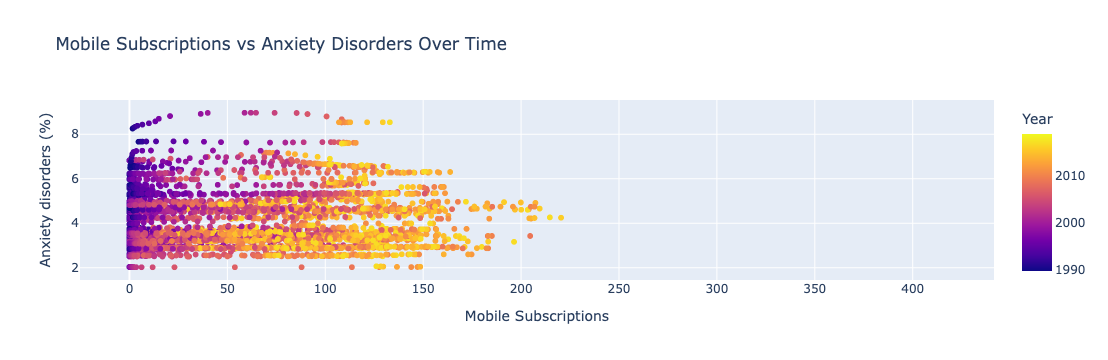

In [34]:
fig = px.scatter(
    merged,
    x='Mobile Subscriptions',
    y='Anxiety disorders (%)',
    color='Year',
    hover_name='Entity',
    title='Mobile Subscriptions vs Anxiety Disorders Over Time'
)
fig.show()

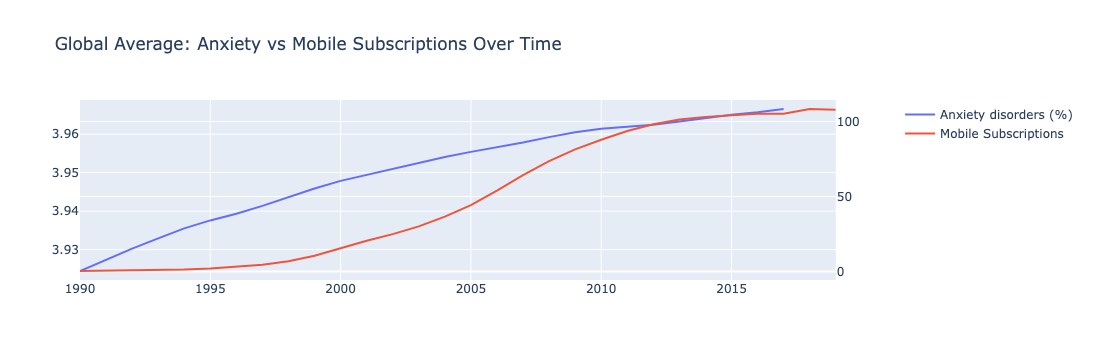

In [35]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

yearly = merged.groupby('Year').agg({
    'Anxiety disorders (%)': 'mean',
    'Mobile Subscriptions': 'mean'
}).reset_index()

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(x=yearly['Year'], y=yearly['Anxiety disorders (%)'], name='Anxiety disorders (%)'),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(x=yearly['Year'], y=yearly['Mobile Subscriptions'], name='Mobile Subscriptions'),
    secondary_y=True
)

fig.update_layout(title='Global Average: Anxiety vs Mobile Subscriptions Over Time')
fig.show()

## Key Finding: Global Averages
Global average anxiety shows minimal increase 1990-2019 despite mobile subscriptions 
rising dramatically. Challenges simple smartphone = anxiety narrative. 
Regional breakdowns likely to reveal more nuanced patterns.

## Plotting by Region

In [36]:
print(merged['Entity'].unique()[:20])

<StringArray>
[        'Afghanistan',             'Albania',             'Algeria',
      'American Samoa',             'Andorra',              'Angola',
 'Antigua and Barbuda',           'Argentina',             'Armenia',
           'Australia',             'Austria',          'Azerbaijan',
             'Bahamas',             'Bahrain',          'Bangladesh',
            'Barbados',             'Belarus',             'Belgium',
              'Belize',               'Benin']
Length: 20, dtype: str


In [37]:
import pycountry_convert as pc

def get_continent(country_code):
    try:
        continent_code = pc.country_alpha2_to_continent_code(
            pc.country_alpha3_to_country_alpha2(country_code)
        )
        continent_map = {
            'AF': 'Africa',
            'AS': 'Asia',
            'EU': 'Europe',
            'NA': 'North America',
            'SA': 'South America',
            'OC': 'Oceania'
        }
        return continent_map.get(continent_code, 'Unknown')
    except:
        return 'Unknown'

merged['Region'] = merged['Code'].apply(get_continent)
print(merged['Region'].value_counts())

Region
Africa           6264
Asia             5572
Europe           5000
North America    3436
Oceania          1924
South America    1392
Unknown           176
Name: count, dtype: int64


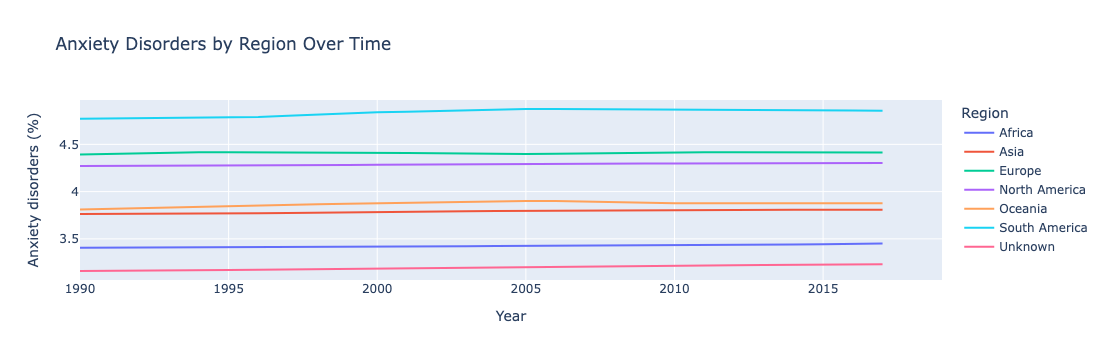

In [38]:
regional = merged.groupby(['Year', 'Region']).agg({
    'Anxiety disorders (%)': 'mean',
    'Mobile Subscriptions': 'mean'
}).reset_index()

fig = px.line(
    regional,
    x='Year',
    y='Anxiety disorders (%)',
    color='Region',
    title='Anxiety Disorders by Region Over Time'
)
fig.show()

## Regional Anxiety Patterns
South America shows consistently highest anxiety rates globally 1990-2019.
Africa and Asia show lowest rates despite lower mobile adoption.
No region shows dramatic increase over time.
Challenges assumption that digital connectivity drives anxiety prevalence.

## Focusing on Smaller High Connectivity Countries 

In [39]:
high_connectivity = [
    'KOR', 'SGP', 'ISL', 'NLD', 'CHE', 'DNK', 'SWE', 'NOR', 'FIN', 'GBR',
    'DEU', 'AUS', 'JPN', 'EST', 'LUX'
]

merged_hc = merged[merged['Code'].isin(high_connectivity)]
print(merged_hc['Entity'].unique())
print(merged_hc.shape)

<StringArray>
[     'Australia',        'Denmark',        'Estonia',        'Finland',
        'Germany',        'Iceland',          'Japan',     'Luxembourg',
    'Netherlands',         'Norway',      'Singapore',    'South Korea',
         'Sweden',    'Switzerland', 'United Kingdom']
Length: 15, dtype: str
(1740, 15)


## High Connectivity Country Filter
Filtered to 15 small/highly connected nations where country-level averages 
are more meaningful. Reduces noise from large countries with huge urban/rural divides.

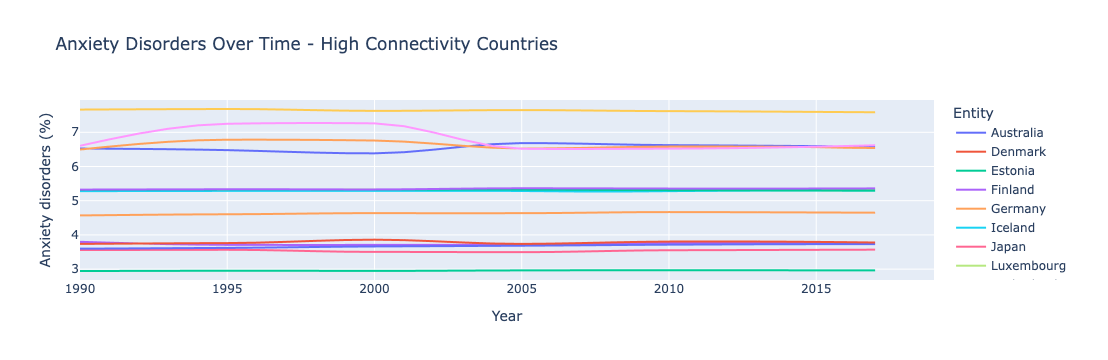

In [40]:
fig = px.line(
    merged_hc,
    x='Year',
    y='Anxiety disorders (%)',
    color='Entity',
    title='Anxiety Disorders Over Time - High Connectivity Countries'
)
fig.show()

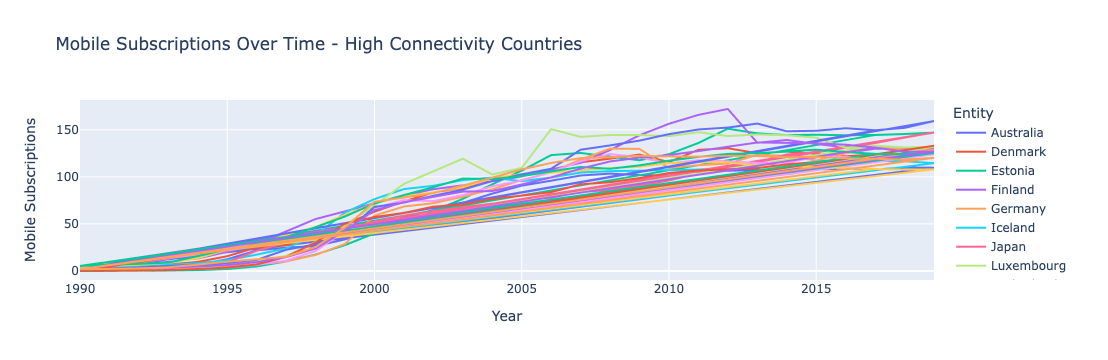

In [41]:
fig = px.line(
    merged_hc,
    x='Year',
    y='Mobile Subscriptions',
    color='Entity',
    title='Mobile Subscriptions Over Time - High Connectivity Countries'
)
fig.show()

## Key Finding: High Connectivity Countries
Mobile subscriptions rose dramatically from near zero to 100-150+ per 100 people 
across all high connectivity nations between 1990-2019.
Anxiety disorders remained essentially flat across the same period.
The data does not support a simple causal relationship between mobile adoption and anxiety prevalence.

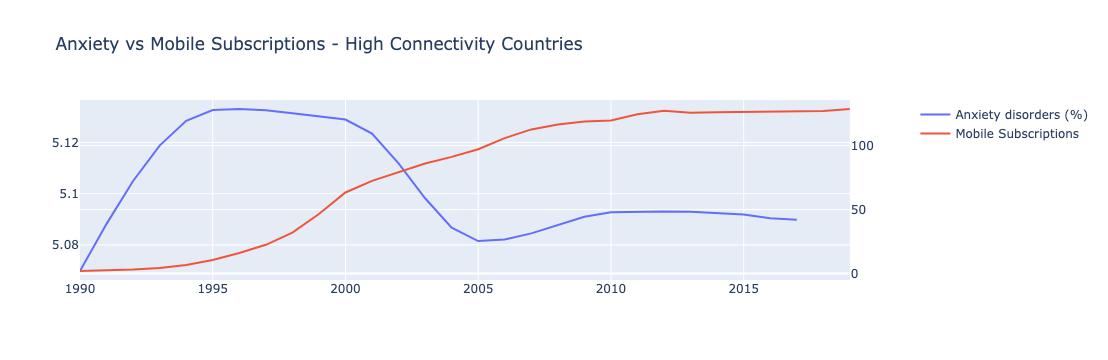

In [42]:
hc_yearly = merged_hc.groupby('Year').agg({
    'Anxiety disorders (%)': 'mean',
    'Mobile Subscriptions': 'mean'
}).reset_index()

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(x=hc_yearly['Year'], y=hc_yearly['Anxiety disorders (%)'], name='Anxiety disorders (%)'),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(x=hc_yearly['Year'], y=hc_yearly['Mobile Subscriptions'], name='Mobile Subscriptions'),
    secondary_y=True
)

fig.update_layout(title='Anxiety vs Mobile Subscriptions - High Connectivity Countries')
fig.show()

## Final Finding: Anxiety Peaks Before Mobile Adoption
In high connectivity countries, anxiety peaked around 1995 and declined 
as mobile subscriptions rose. Directly contradicts the popular narrative 
that smartphone adoption drives anxiety. Causation cannot be inferred — 
but the data demands a more nuanced conversation.
Next step: city-level analysis to test whether this pattern holds at finer resolution.

## Notebook Summary & Next Steps
This notebook explored country-level mental health and mobile subscription data.
Key limitation: country averages mask urban/rural differences.
Next notebook: UK regional or city-level analysis using ONS data.